<a href="https://colab.research.google.com/github/FatemehKhawari/machine-learning-case-studies/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Goal: Predict the price of a house based on its characteristics (area, rooms, location, etc.)


In [ ]:
# required libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (LinearRegression, Ridge , Lasso)
from sklearn.ensemble import (RandomForestRegressor , GradientBoostingRegressor)
from sklearn.metrics import (mean_absolute_error , mean_squared_error , r2_score)

In [ ]:
#Load Dataset
housing = fetch_california_housing ()
df = pd.DataFrame( housing.data , columns = housing.feature_names)
df ["price"] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Explore Dataset
print (" number of samples:" , df.shape [0])
print (" number of features:" , df.shape[1] - 1)
#Why mines one?!
# or print("Number of features:", len(housing.feature_names))
print (" featur names: " , housing.feature_names)
print ("Missing values:" , df.isnull().sum().sum())
print("statistics:" , df.describe())

 number of samples: 20640
 number of features: 8
 featur names:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Missing values: 0
statistics:              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         price  
count  20640.000000  20640.000

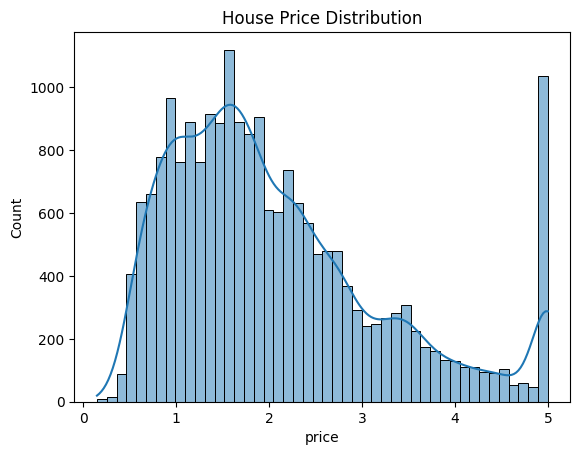

In [ ]:
#data visualization
sns.histplot(df["price"] , kde = True)
plt.title("House Price Distribution")
plt.show()


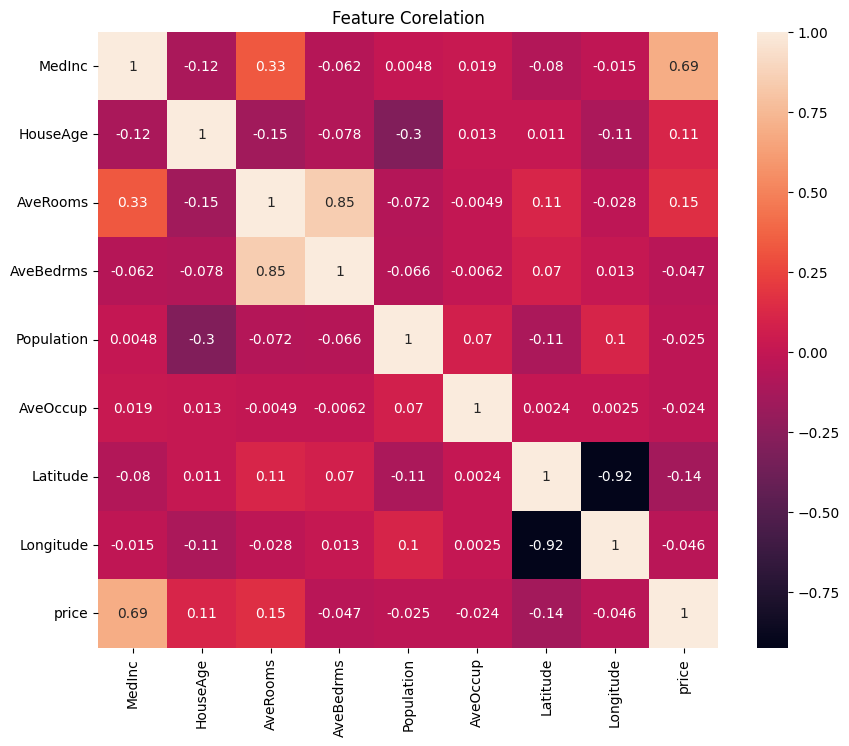

In [ ]:
#corelation matrix
corelation = df.corr()
plt.figure(figsize = (10 , 8))
sns.heatmap (corelation , annot = True)
plt.title ("Feature Corelation")
plt.show()

In [ ]:
#Data Preparation
x = df.drop("price" , axis = 1)
y = df["price"]

In [ ]:
#split data in training and testing sets
x_train , x_test , y_train , y_test = train_test_split( x , y ,test_size = 0.2 , random_state = 42)

In [ ]:
#create models
Models = {
    "Linear Regression":
    Pipeline([
        ("scaler" , StandardScaler ()),
        ("model" , LinearRegression())
    ]),

    "Lasso regression":
    Pipeline([
        ("scaler", StandardScaler),
        ("model" , Lasso())
    ]),
    "Ridge Regression":
    Pipeline([
        ("scaler" , StandardScaler),
        ("model" , Ridge())
    ]),
    "Random Forest":
    RandomForestRegressor(random_state =42),
    "Gradient Boosting":
    GradientBoostingRegressor(random_state = 42)
}

In [ ]:
#Train Models
#results []
for name , mode in models.items():
  #train
  model.fit(x_train , y_train)
  #predict
  y_pred = model.predict (x_test)
  #metrics
  mae = mean_absolute_error (y_test , y_pred)
  rmse = np.sqrt(mean_squared_error(y_test , y_pred))
  r2 = r2_score (y_test , y_pred)

NameError: name 'models' is not defined